# Models for Real News

## Imports

In [11]:
# reading df
import pandas as pd

# Model Libs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

from joblib import dump


## Introduction

In this notebook we will prepare the data (vectorize it and split it) to fit into several models. These models include a logistic regression, random forest and SVM. In addition, it will provide the top 5 words that were indicators of real articles.

## Prep data

In [2]:
df = pd.read_csv("DF_final.csv")

x_train, x_test, y_train, y_test = train_test_split(
    df["text_clean"], df["label"], 
    test_size = 0.3, random_state = 42, 
    stratify = df["label"])


In [3]:
# Vecotrizing
vect = TfidfVectorizer(
    max_features = 1000,
    min_df = 10,
    ngram_range = (1, 3)
)

x_train_vec = vect.fit_transform(x_train)
x_test_vec = vect.transform(x_test)

In [ ]:
dump(vect, "vectorizer_rn.joblib")

## Model 1: Logistic Regression

First we tried a logistic regession with minimal tuning.

In [5]:
log_reg = LogisticRegression(solver = "liblinear", random_state = 42)
log_reg.fit(x_train_vec, y_train)
pred_log = log_reg.predict(x_test_vec)

print(f"Accuracy: {accuracy_score(y_test, pred_log)}")
print(classification_report(y_test, pred_log))

Accuracy: 0.9644495412844036
              precision    recall  f1-score   support

           0       0.97      0.96      0.96      5232
           1       0.96      0.97      0.96      5232

    accuracy                           0.96     10464
   macro avg       0.96      0.96      0.96     10464
weighted avg       0.96      0.96      0.96     10464



Text(70.72222222222221, 0.5, 'Actual Label')

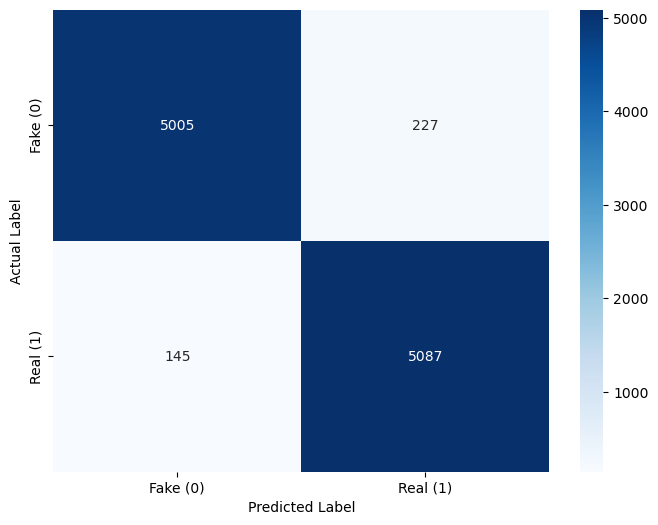

In [6]:
cm = confusion_matrix(y_test, pred_log)

plt.figure(figsize = (8, 6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = ["Fake (0)", "Real (1)"],
            yticklabels = ["Fake (0)", "Real (1)"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
            

In [7]:
# To check if overfittign occurs
train_acc = log_reg.score(x_train_vec, y_train)
test_acc = log_reg.score(x_test_vec, y_test)

print(f"Train acc: {train_acc}")
print(f"Test acc: {test_acc}")

Train acc: 0.9720265399737876
Test acc: 0.9644495412844036


Then we wanted to apply a grid search to try and optimize the results even  further.

In [8]:
def run_grid_search(model, params):
    mod = None
    if model == "Log reg":
        mod = LogisticRegression(random_state = 42)
    elif model == "Rand for class":
        mod = RandomForestClassifier(random_state = 42)
    else:
        mod = LinearVC(dual = False, random_state = 42)
        model = "SVC"

    grid_search = GridSearchCV(
        estimator = mod,
        param_grid = params,
        cv = 5,
        scoring = "accuracy",
        n_jobs = -1)

    grid_search.fit(x_train_vec, y_train)

    best_mod = grid_search.best_estimator_

    y_pred = best_mod.predict(x_test_vec)

    train_acc = best_mod.score(x_train_vec, y_train)
    test_acc = best_mod.score(x_test_vec, y_test)

    print(f" - Results for {model} -")
    print(f"Best Params: {grid_search.best_params_}")
    print(f"Final Test Acc: {round(test_acc, 2)}")
    print(f"Final Train Acc: {round(train_acc, 2)}")
    print(f"\n Classification Report:")
    print(classification_report(y_test, y_pred))
   
    
    return best_mod
    

In [9]:
parameters_grid_log = [{"solver": ["liblinear", "saga"],
                    "penalty": ["l1", "l2"],
                    "C": [0.1, 1, 3, 6, 10],
                    "max_iter": [100, 500, 1000]}, 
                   {"solver": ["lbfgs", "newton-cg"],
                    "penalty": ["l2"],
                    "C": [0.1, 1, 3, 6, 10],
                    "max_iter": [100, 500, 1000]}]
results_log_reg = run_grid_search("Log reg", parameters_grid_log)

 - Results for Log reg -
Best Params: {'C': 3, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Final Test Acc: 0.97
Final Train Acc: 0.98

 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      5232
           1       0.96      0.97      0.97      5232

    accuracy                           0.97     10464
   macro avg       0.97      0.97      0.97     10464
weighted avg       0.97      0.97      0.97     10464



In [12]:
dump(results_log_reg, "log_reg_rn.joblib")

['log_reg_rn.joblib']

## Model 2: Random Forest

In [ ]:
parameters_grid_rand = {"n_estimators": [50, 100, 200],
                      "max_depth": [5, 10, 20],
                      "min_samples_leaf": [2, 5, 10],
                      "min_samples_split": [4, 8, 12]}
results_rand = run_grid_search("Rand for class", parameters_grid_rand)

In [ ]:
dump(results_rand, "rand_for_rn.joblib")

# Model 3: SVC (SVM)

In [ ]:
parameters_grid_svc = {"C": [0.1, 1, 3, 6, 10],
                       "max_iter": [2500],
                      "class_weight":["balanced"]} 
results_svc = run_grid_search("SVC", parameters_grid_svc)

In [ ]:
dump(results_svc, "svc_rn.joblib")